<a href="https://colab.research.google.com/github/Lawson-Dong/ESINDy_infra/blob/main/Bagging_and_Stacking_and_Boosting(F1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Meta-Learner Comparison: Ridge vs. Lasso vs. STLS (No Normalization, Threshold=0.1, n_runs=10)

--- Noise: σ=0.0 ---
  Training Stacking (RIDGE)...
    RMSE: 0.014920, F1: 0.9308, Time: 0.42s
  Training Stacking (LASSO)...
    RMSE: 0.032633, F1: 0.9231, Time: 0.64s
  Training Stacking (STLS)...
    RMSE: 0.013583, F1: 0.9308, Time: 0.38s

--- Noise: σ=0.1 ---
  Training Stacking (RIDGE)...
    RMSE: 0.006821, F1: 0.9923, Time: 0.47s
  Training Stacking (LASSO)...
    RMSE: 0.027329, F1: 0.9867, Time: 0.61s
  Training Stacking (STLS)...
    RMSE: 0.004579, F1: 1.0000, Time: 0.47s

--- Noise: σ=0.3 ---
  Training Stacking (RIDGE)...
    RMSE: 0.011238, F1: 1.0000, Time: 0.68s
  Training Stacking (LASSO)...
    RMSE: 0.016791, F1: 0.9533, Time: 0.91s
  Training Stacking (STLS)...
    RMSE: 0.009813, F1: 1.0000, Time: 0.62s

--- Noise: σ=0.5 ---
  Training Stacking (RIDGE)...
    RMSE: 0.024063, F1: 0.7778, Time: 0.63s
  Training Stacking (LASSO)...
    RMSE: 0.031487, F1: 0.7409, Time: 0

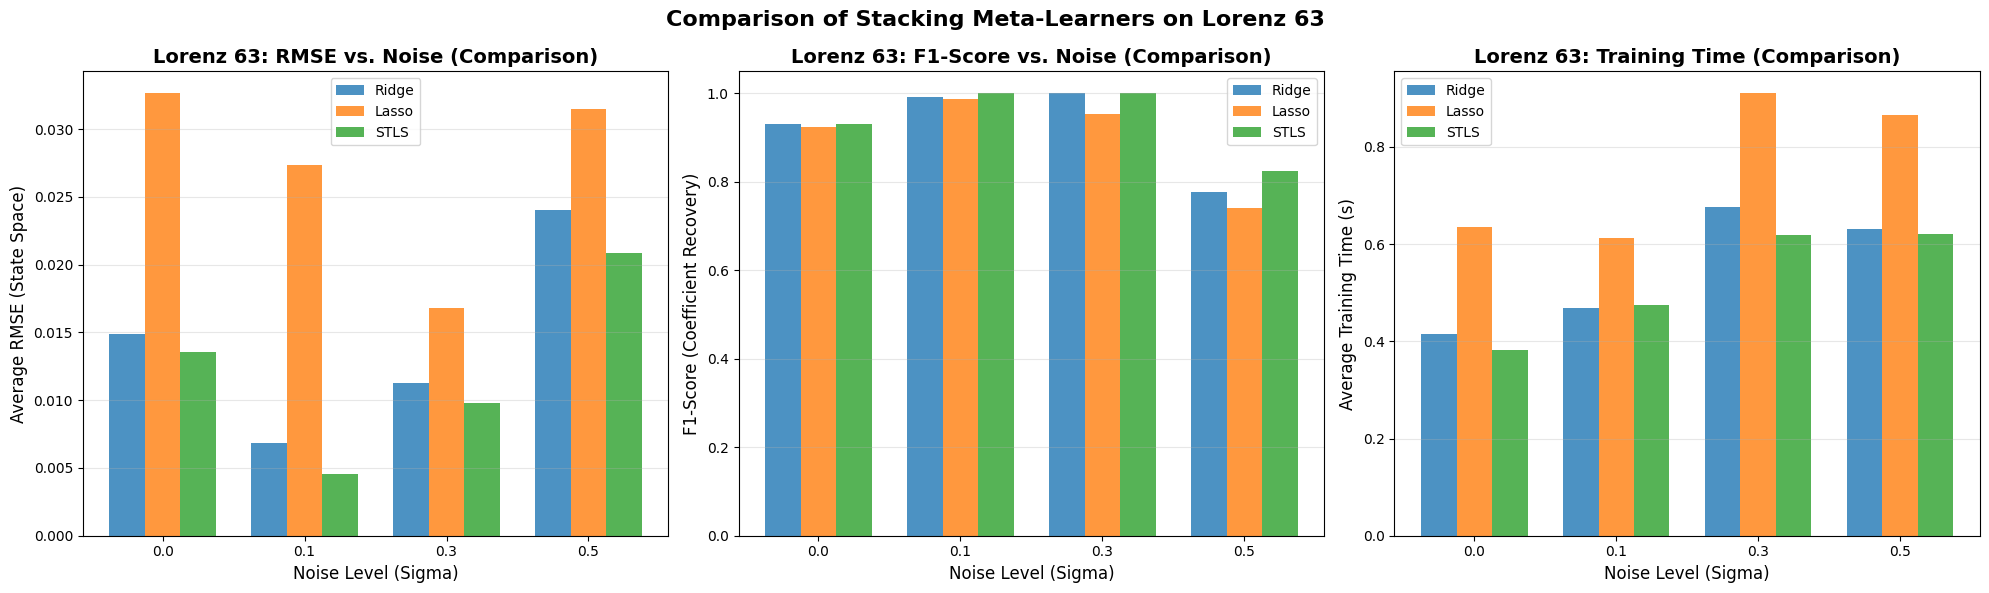


Experiment completed successfully!


In [6]:
# =============================================================================
# Part 1: Import Libraries and Setup
# =============================================================================
!pip install scikit-learn matplotlib numpy scipy -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import savgol_filter
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import warnings
import time

warnings.filterwarnings('ignore')

# =============================================================================
# Part 2: Base SINDy Framework
# =============================================================================

class BaseSINDy:
    """Base class for SINDy with common utility functions."""
    def __init__(self, **kwargs):
        self.poly_degree = kwargs.get('poly_degree', 2)
        self.threshold = kwargs.get('threshold', 0.15)
        self.sg_window = kwargs.get('sg_window', 11)
        self.sg_order = kwargs.get('sg_order', 3)
        self.use_reduced_features = kwargs.get('use_reduced_features', True)
        self.feature_names = None

    def _compute_derivative_sg(self, X, dt):
        n_samples, n_states = X.shape
        dX = np.zeros_like(X)
        for i in range(n_states):
            X_smoothed = savgol_filter(X[:, i], self.sg_window, self.sg_order)
            dX[:, i] = np.gradient(X_smoothed, dt)
        return dX

    def _create_reduced_features(self, X):
        x = X[:, 0:1]; y = X[:, 1:2]; z = X[:, 2:3]
        features = [x, y, z, x*y, x*z, y*z]
        Theta = np.hstack(features)
        self.feature_names = ['x', 'y', 'z', 'x*y', 'x*z', 'y*z']
        return Theta

    def _create_polynomial_features(self, X):
        if self.use_reduced_features:
            return self._create_reduced_features(X)
        else:
            if not hasattr(self, 'poly'):
                self.poly = PolynomialFeatures(degree=self.poly_degree, include_bias=False)
                Theta = self.poly.fit_transform(X)
            else:
                Theta = self.poly.transform(X)
            return Theta

class BaggingSINDy(BaseSINDy):
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.subsample_ratio = kwargs.pop('subsample_ratio', 0.8)
        self.noise_std = kwargs.pop('noise_std', 0.05)
        self.models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X)
        self.models = []
        for i in range(self.n_estimators):
            try:
                indices = np.random.choice(n_samples, int(n_samples * self.subsample_ratio), replace=True)
                Theta_sample = Theta[indices].copy()
                dX_sample = dX[indices].copy()
                if self.noise_std > 0:
                    Theta_sample += np.random.normal(0, self.noise_std, Theta_sample.shape)
                    dX_sample += np.random.normal(0, self.noise_std, dX_sample.shape)
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_sample, dX_sample[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                self.models.append(np.array(coeffs))
            except Exception:
                continue
        self.final_coefficients = np.median(self.models, axis=0)
        return self

    def predict_derivative(self, X):
        if X.ndim == 1: X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X)
        return Theta @ self.final_coefficients.T

class BoostingSINDy(BaseSINDy):
    def __init__(self, **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.learning_rate = kwargs.pop('learning_rate', 0.1)
        self.models = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX_true = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X)
        self.final_coefficients = np.zeros((n_states, Theta.shape[1]))
        self.models = []
        dX_residual = dX_true.copy()
        for i in range(self.n_estimators):
            try:
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta, dX_residual[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.final_coefficients += self.learning_rate * coeffs
                dX_pred = Theta @ coeffs.T
                dX_residual -= self.learning_rate * dX_pred
                self.models.append(coeffs)
            except Exception:
                continue
        return self

    def predict_derivative(self, X):
        if X.ndim == 1: X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X)
        return Theta @ self.final_coefficients.T

# =============================================================================
# Part 3: StackingSINDy with Three Different Meta-Learners (Non‑normalized)
# =============================================================================

class StackingSINDy(BaseSINDy):
    """Stacking with configurable meta-learner. Coefficients are NOT normalized after aggregation."""
    def __init__(self, meta_learner='ridge', **kwargs):
        self.n_estimators = kwargs.pop('n_estimators', 50)
        self.meta_learner_type = meta_learner  # 'ridge', 'lasso', 'stls'
        self.meta_alpha = kwargs.pop('meta_alpha', 1.0)
        self.meta_threshold = kwargs.pop('meta_threshold', 0.15)
        self.base_models = []
        self.meta_weights = []
        self.final_coefficients = None
        super().__init__(**kwargs)

    def fit(self, X, dt, verbose=False):
        n_samples, n_states = X.shape
        dX = self._compute_derivative_sg(X, dt)
        Theta = self._create_polynomial_features(X)
        n_features = Theta.shape[1]
        self.base_models = []
        base_predictions = []

        # Train base models
        for i in range(self.n_estimators):
            try:
                train_idx = np.random.choice(n_samples, int(n_samples * 0.8), replace=False)
                Theta_train = Theta[train_idx]
                dX_train = dX[train_idx]
                coeffs = []
                for j in range(n_states):
                    lasso = Lasso(alpha=self.threshold, max_iter=10000, random_state=i)
                    lasso.fit(Theta_train, dX_train[:, j])
                    coef = lasso.coef_
                    coef[np.abs(coef) < self.threshold] = 0
                    coeffs.append(coef)
                coeffs = np.array(coeffs)
                self.base_models.append(coeffs)
                base_predictions.append(Theta @ coeffs.T)
            except Exception:
                continue

        if len(self.base_models) == 0:
            raise RuntimeError("All base models failed.")

        base_predictions = np.array(base_predictions)  # [n_estimators, n_samples, n_states]
        self.final_coefficients = np.zeros((n_states, n_features))
        self.meta_weights = []

        # Train meta-learner
        for j in range(n_states):
            X_meta = base_predictions[:, :, j].T  # [n_samples, n_estimators]
            y_meta = dX[:, j]

            if self.meta_learner_type == 'ridge':
                model = Ridge(alpha=self.meta_alpha)
                model.fit(X_meta, y_meta)
                w = model.coef_
            elif self.meta_learner_type == 'lasso':
                model = Lasso(alpha=self.meta_alpha, max_iter=10000)
                model.fit(X_meta, y_meta)
                w = model.coef_
            elif self.meta_learner_type == 'stls':
                # STLS for meta-learner
                w = np.linalg.lstsq(X_meta, y_meta, rcond=None)[0]
                for _ in range(10):
                    mask = np.abs(w) > self.meta_threshold
                    if not np.any(mask): break
                    X_restricted = X_meta[:, mask]
                    w_restricted = np.linalg.lstsq(X_restricted, y_meta, rcond=None)[0]
                    w_new = np.zeros_like(w)
                    w_new[mask] = w_restricted
                    if np.array_equal(mask, np.abs(w_new) > self.meta_threshold):
                        w = w_new; break
                    w = w_new
            else:
                raise ValueError(f"Unknown meta-learner type: {self.meta_learner_type}")

            self.meta_weights.append(w)
            # Aggregate coefficients WITHOUT normalization
            weighted_coeffs = np.zeros(n_features)
            for k, w_meta in enumerate(w):
                if k < len(self.base_models):
                    weighted_coeffs += w_meta * self.base_models[k][j]
            # 直接使用原始聚合系数，不再除以总和
            self.final_coefficients[j] = weighted_coeffs

        return self

    def predict_derivative(self, X):
        if X.ndim == 1: X = X.reshape(1, -1)
        Theta = self._create_polynomial_features(X)
        base_preds = []
        for model in self.base_models:
            base_preds.append(Theta @ model.T)
        base_preds = np.array(base_preds)
        n_samples = X.shape[0]; n_states = self.final_coefficients.shape[0]
        final_pred = np.zeros((n_samples, n_states))
        for j in range(n_states):
            X_meta = base_preds[:, :, j].T
            final_pred[:, j] = X_meta @ self.meta_weights[j]
        return final_pred

# =============================================================================
# Part 4: Data Generation and Metrics
# =============================================================================

def generate_lorenz_data(sigma=10, beta=8/3, rho=28, x0=[1, 1, 1], t_max=10.0, dt=0.01, noise_std=0.0):
    def lorenz_system(state, t):
        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return [dx, dy, dz]
    t = np.arange(0, t_max, dt)
    X_true = odeint(lorenz_system, x0, t)
    if noise_std > 0:
        X_noisy = X_true + np.random.normal(0, noise_std, X_true.shape)
    else:
        X_noisy = X_true
    return t, X_true, X_noisy

def one_step_prediction_rk4(model, X_test_true, dt):
    n_steps = len(X_test_true)
    X_pred = np.zeros_like(X_test_true)
    X_pred[0] = X_test_true[0]
    def f(state):
        if state.ndim == 1: state = state.reshape(1, -1)
        return model.predict_derivative(state)[0]
    for i in range(n_steps - 1):
        x = X_test_true[i].flatten()
        k1 = f(x)
        if np.any(np.isnan(k1)): continue
        k2 = f(x + 0.5 * dt * k1)
        k3 = f(x + 0.5 * dt * k2)
        k4 = f(x + dt * k3)
        if np.any(np.isnan(k2)) or np.any(np.isnan(k3)) or np.any(np.isnan(k4)): continue
        X_pred[i+1] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return X_pred

def calculate_rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if np.sum(mask) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def get_ground_truth_mask(feature_names, state_idx):
    if state_idx == 0: gt = [0, 1]          # x, y
    elif state_idx == 1: gt = [0, 1, 4]     # x, y, x*z
    elif state_idx == 2: gt = [2, 3]        # z, x*y
    else: gt = []
    mask = np.zeros(len(feature_names), dtype=bool)
    mask[gt] = True
    return mask

def evaluate_coefficient_recovery(model, feature_names, threshold=0.15):
    if model.final_coefficients is None: return 0.0
    n_states, n_features = model.final_coefficients.shape
    tp, fp, fn = 0, 0, 0
    for j in range(n_states):
        coeffs = model.final_coefficients[j]
        predicted_mask = np.abs(coeffs) > threshold
        true_mask = get_ground_truth_mask(feature_names, j)
        tp += np.sum(predicted_mask & true_mask)
        fp += np.sum(predicted_mask & ~true_mask)
        fn += np.sum(~predicted_mask & true_mask)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

# =============================================================================
# Part 5: Run Meta-Learner Comparison Experiment
# =============================================================================

def run_meta_learner_comparison(generate_data_func, config, X0_test, noise_levels, n_runs=3, verbose=True):
    """Compare Ridge, Lasso, and STLS as meta-learners for Stacking."""
    meta_learners = ['ridge', 'lasso', 'stls']
    results = {ml: {'rmse': [], 'f1': [], 'time': []} for ml in meta_learners}

    _, X_true_test, _ = generate_data_func(noise_std=0, **config['system_kwargs'])
    eval_steps = int(config['eval_window'] / config['dt'])
    X_true_test_eval = X_true_test[:eval_steps]

    for noise_std in noise_levels:
        if verbose: print(f"\n--- Noise: σ={noise_std} ---")
        _, _, X_noisy_train = generate_data_func(noise_std=noise_std, **config['system_kwargs'])

        for ml_type in meta_learners:
            if verbose: print(f"  Training Stacking ({ml_type.upper()})...")

            rmse_vals = []
            f1_vals = []
            time_vals = []

            for run in range(n_runs):
                model = StackingSINDy(meta_learner=ml_type, **config['sindy_kwargs'])
                t0 = time.time()
                model.fit(X_noisy_train, dt=config['dt'], verbose=False)
                t_train = time.time() - t0
                X_pred = one_step_prediction_rk4(model, X_true_test_eval, config['dt'])
                rmse = calculate_rmse(X_true_test_eval.flatten(), X_pred.flatten())

                # 使用配置中的阈值评估系数恢复
                f1 = evaluate_coefficient_recovery(model, model.feature_names,
                                                   threshold=config['sindy_kwargs']['threshold'])

                rmse_vals.append(rmse)
                f1_vals.append(f1)
                time_vals.append(t_train)

            results[ml_type]['rmse'].append(np.mean(rmse_vals))
            results[ml_type]['f1'].append(np.mean(f1_vals))
            results[ml_type]['time'].append(np.mean(time_vals))
            if verbose:
                print(f"    RMSE: {np.mean(rmse_vals):.6f}, F1: {np.mean(f1_vals):.4f}, Time: {np.mean(time_vals):.2f}s")
    return results

def plot_meta_learner_comparison(results, system_name):
    """Plot comparison of Ridge, Lasso, and STLS meta-learners."""
    noise_levels = [0.0, 0.1, 0.3, 0.5]
    meta_learners = ['ridge', 'lasso', 'stls']
    labels = ['Ridge', 'Lasso', 'STLS']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    x_pos = np.arange(len(noise_levels))
    width = 0.25

    # 1. RMSE Comparison
    ax = axes[0]
    for i, ml in enumerate(meta_learners):
        means = results[ml]['rmse']
        ax.bar(x_pos + i*width, means, width, label=labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Average RMSE (State Space)', fontsize=12)
    ax.set_title(f'{system_name}: RMSE vs. Noise (Comparison)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 2. F1-Score Comparison
    ax = axes[1]
    for i, ml in enumerate(meta_learners):
        means = results[ml]['f1']
        ax.bar(x_pos + i*width, means, width, label=labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('F1-Score (Coefficient Recovery)', fontsize=12)
    ax.set_title(f'{system_name}: F1-Score vs. Noise (Comparison)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

    # 3. Training Time Comparison
    ax = axes[2]
    for i, ml in enumerate(meta_learners):
        means = results[ml]['time']
        ax.bar(x_pos + i*width, means, width, label=labels[i], color=colors[i], alpha=0.8)
    ax.set_xlabel('Noise Level (Sigma)', fontsize=12)
    ax.set_ylabel('Average Training Time (s)', fontsize=12)
    ax.set_title(f'{system_name}: Training Time (Comparison)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'{nl}' for nl in noise_levels])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Comparison of Stacking Meta-Learners on {system_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# Part 6: Execution
# =============================================================================

# 修改阈值从 0.15 降低到 0.1
config = {
    'dt': 0.01,
    'eval_window': 5.0,
    'sindy_kwargs': {
        'poly_degree': 2, 'threshold': 0.1,  # 降低阈值
        'sg_window': 11, 'sg_order': 3,
        'n_estimators': 30, 'use_reduced_features': True,
        'meta_alpha': 1.0, 'meta_threshold': 0.1  # meta_threshold 也相应调整，保持一致性
    },
    'system_kwargs': {'sigma': 10, 'beta': 8/3, 'rho': 28, 't_max': 15.0}
}
X0_test = [1.5, 1.5, 1.5]

print("="*80)
print("Meta-Learner Comparison: Ridge vs. Lasso vs. STLS (No Normalization, Threshold=0.1, n_runs=10)")
print("="*80)

comparison_results = run_meta_learner_comparison(
    generate_lorenz_data,
    config,
    X0_test,
    noise_levels=[0.0, 0.1, 0.3, 0.5],
    n_runs=10,  # 修改：从3次增加到10次，取平均值
    verbose=True
)

plot_meta_learner_comparison(comparison_results, "Lorenz 63")

print("\nExperiment completed successfully!")